# Ablation Study on the Delta-A attributes

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np

> Check what atributes are actually there

In [ ]:
C2_DATA = '/zhome/d0/a/221493/thesis/results/C2_custom/c2_data.csv'

In [ ]:
# Load C2 data
c2_data = pd.read_csv(C2_DATA)
c2_data

In [5]:
# Print basic info
print('Size of df:', len(c2_data))

Size of df: 45155


In [11]:
# Check columns
columns = c2_data.columns

# Remove columns starting with "emb"
columns_to_drop = [col for col in columns if col.startswith("emb") or col == 'path' or col == 'pred'or col == 'prob' or col == 'true' or col == 'correct' or col == 'margin' or col =='patient_id']
print(f"Dropping {len(columns_to_drop)} columns starting with 'emb'")

c2_data = c2_data.drop(columns=columns_to_drop)
print("Remaining columns:")
for col in c2_data.columns:
    print(f" - {col}")
    
print("Number of columns after dropping:", len(c2_data.columns))

Dropping 0 columns starting with 'emb'
Remaining columns:
 - age_pred
 - sex_male
 - sex_female
 - race_white
 - race_black
 - race_asian
 - Left Clavicle_area_pixels
 - Left Clavicle_bbox_width
 - Left Clavicle_bbox_height
 - Left Clavicle_bbox_ratio
 - Left Clavicle_perimeter
 - Left Clavicle_original_shape2D_Elongation
 - Left Clavicle_original_shape2D_MajorAxisLength
 - Left Clavicle_original_shape2D_MaximumDiameter
 - Left Clavicle_original_shape2D_MeshSurface
 - Left Clavicle_original_shape2D_MinorAxisLength
 - Left Clavicle_original_shape2D_Perimeter
 - Left Clavicle_original_shape2D_PerimeterSurfaceRatio
 - Left Clavicle_original_shape2D_PixelSurface
 - Left Clavicle_original_shape2D_Sphericity
 - Left Clavicle_original_firstorder_10Percentile
 - Left Clavicle_original_firstorder_90Percentile
 - Left Clavicle_original_firstorder_Energy
 - Left Clavicle_original_firstorder_Entropy
 - Left Clavicle_original_firstorder_InterquartileRange
 - Left Clavicle_original_firstorder_Kurtos

In [12]:
# Check teh fold to see what attributes are delta
fold_df = pd.read_csv('/zhome/d0/a/221493/thesis/results/C2_custom/effusion/cv_results/cf_16/fold_0_predictions.csv')

In [13]:
for column in fold_df.columns:
    print(column)

path
effusion_prob
effusion_true
emb_0
emb_1
emb_2
emb_3
emb_4
emb_5
emb_6
emb_7
emb_8
emb_9
emb_10
emb_11
emb_12
emb_13
emb_14
emb_15
emb_16
emb_17
emb_18
emb_19
emb_20
emb_21
emb_22
emb_23
emb_24
emb_25
emb_26
emb_27
emb_28
emb_29
emb_30
emb_31
emb_32
emb_33
emb_34
emb_35
emb_36
emb_37
emb_38
emb_39
emb_40
emb_41
emb_42
emb_43
emb_44
emb_45
emb_46
emb_47
emb_48
emb_49
emb_50
emb_51
emb_52
emb_53
emb_54
emb_55
emb_56
emb_57
emb_58
emb_59
emb_60
emb_61
emb_62
emb_63
emb_64
emb_65
emb_66
emb_67
emb_68
emb_69
emb_70
emb_71
emb_72
emb_73
emb_74
emb_75
emb_76
emb_77
emb_78
emb_79
emb_80
emb_81
emb_82
emb_83
emb_84
emb_85
emb_86
emb_87
emb_88
emb_89
emb_90
emb_91
emb_92
emb_93
emb_94
emb_95
emb_96
emb_97
emb_98
emb_99
emb_100
emb_101
emb_102
emb_103
emb_104
emb_105
emb_106
emb_107
emb_108
emb_109
emb_110
emb_111
emb_112
emb_113
emb_114
emb_115
emb_116
emb_117
emb_118
emb_119
emb_120
emb_121
emb_122
emb_123
emb_124
emb_125
emb_126
emb_127
emb_128
emb_129
emb_130
emb_131
emb_132
emb_133
emb_1

In [14]:
# tHE ONES THAT START WITH "delta_" ARE THE DELTA ATTRIBUTES, THE REST ARE THE ORIGINAL ONES.
delta_attributes = [col for col in fold_df.columns if col.startswith("delta_")]
print("Delta attributes:")
for attr in delta_attributes:
    print(f" - {attr}")

Delta attributes:
 - delta_margin
 - delta_age_pred
 - delta_sex_male
 - delta_sex_female
 - delta_race_white
 - delta_race_black
 - delta_race_asian
 - delta_Left Clavicle_area_pixels
 - delta_Left Clavicle_bbox_width
 - delta_Left Clavicle_bbox_height
 - delta_Left Clavicle_bbox_ratio
 - delta_Left Clavicle_perimeter
 - delta_Left Clavicle_original_shape2D_Elongation
 - delta_Left Clavicle_original_shape2D_MajorAxisLength
 - delta_Left Clavicle_original_shape2D_MaximumDiameter
 - delta_Left Clavicle_original_shape2D_MeshSurface
 - delta_Left Clavicle_original_shape2D_MinorAxisLength
 - delta_Left Clavicle_original_shape2D_Perimeter
 - delta_Left Clavicle_original_shape2D_PerimeterSurfaceRatio
 - delta_Left Clavicle_original_shape2D_PixelSurface
 - delta_Left Clavicle_original_shape2D_Sphericity
 - delta_Left Clavicle_original_firstorder_10Percentile
 - delta_Left Clavicle_original_firstorder_90Percentile
 - delta_Left Clavicle_original_firstorder_Energy
 - delta_Left Clavicle_origina

In [ ]:
ORGANS = ["Left Clavicle", "Left Scapula", "Right Scapula", "Left Lung", "Right Lung", "Left Hilus Pulmonis", "Heart", "Facies Diaphragmatica", "Mediastinum", "Weasand", "Spine", "Right Clavicle", "Right Hilus Pulmonis", "Aorta", "Ratio/Fraction" ]

In [34]:
# cCheck how many delta attributes we have for each organ
delta_counts = {organ: 0 for organ in ORGANS}
for attr in delta_attributes:
    for organ in ORGANS:
        if organ in attr:
            delta_counts[organ] += 1    
print("Number of delta attributes per organ:")
for organ, count in delta_counts.items():
    print(f" - {organ}: {count}")

Number of delta attributes per organ:
 - Left Clavicle: 32
 - Left Scapula: 32
 - Right Scapula: 32
 - Left Lung: 32
 - Right Lung: 32
 - Left Hilus Pulmonis: 32
 - Heart: 32
 - Facies Diaphragmatica: 32
 - Mediastinum: 32
 - Weasand: 32
 - Spine: 32
 - Right Clavicle: 32
 - Right Hilus Pulmonis: 32
 - Aorta: 32


Number of delta attributes per organ and type:
 - Left Clavicle: shape2D=9, firstorder=18, demographic=5
 - Left Scapula: shape2D=9, firstorder=18, demographic=5
 - Right Scapula: shape2D=9, firstorder=18, demographic=5
 - Left Lung: shape2D=9, firstorder=18, demographic=5
 - Right Lung: shape2D=9, firstorder=18, demographic=5
 - Left Hilus Pulmonis: shape2D=9, firstorder=18, demographic=5
 - Heart: shape2D=9, firstorder=18, demographic=5
 - Facies Diaphragmatica: shape2D=9, firstorder=18, demographic=5
 - Mediastinum: shape2D=9, firstorder=18, demographic=5
 - Weasand: shape2D=9, firstorder=18, demographic=5
 - Spine: shape2D=9, firstorder=18, demographic=5
 - Right Clavicle: shape2D=9, firstorder=18, demographic=5
 - Right Hilus Pulmonis: shape2D=9, firstorder=18, demographic=5
 - Aorta: shape2D=9, firstorder=18, demographic=5


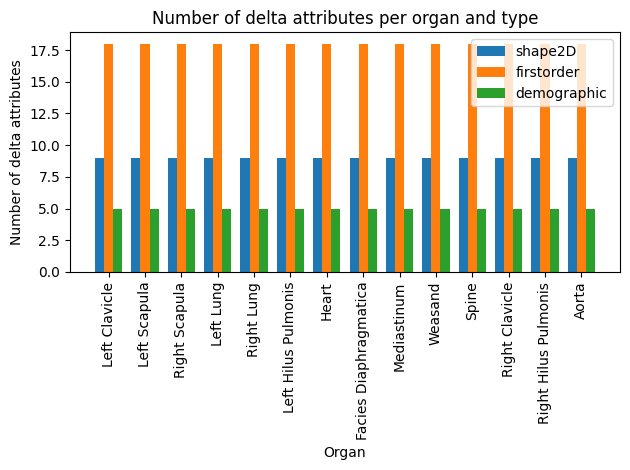

In [35]:
# Count differnt types
# if it includes "shape2d", "firstorder" classify as such
# the others are demographic

# count for each organ
type_counts = {organ: {"shape2D": 0, "firstorder": 0, "demographic": 0} for organ in ORGANS}
for attr in delta_attributes:
    for organ in ORGANS:
        if organ in attr:
            if "shape2D" in attr:
                type_counts[organ]["shape2D"] += 1
            elif "firstorder" in attr:  
                type_counts[organ]["firstorder"] += 1
            else:
                type_counts[organ]["demographic"] += 1  
print("Number of delta attributes per organ and type:")
for organ, counts in type_counts.items():
    print(f" - {organ}: shape2D={counts['shape2D']}, firstorder={counts['firstorder']}, demographic={counts['demographic']}")
    
# SHOW AS A BAR CHART
organs = list(type_counts.keys())
shape2D_counts = [type_counts[organ]["shape2D"] for organ in organs]
firstorder_counts = [type_counts[organ]["firstorder"] for organ in organs]
demographic_counts = [type_counts[organ]["demographic"] for organ in organs]

x = np.arange(len(organs))
width = 0.25    
plt.bar(x - width, shape2D_counts, width, label='shape2D')
plt.bar(x, firstorder_counts, width, label='firstorder')
plt.bar(x + width, demographic_counts, width, label='demographic')
plt.xlabel('Organ')
plt.ylabel('Number of delta attributes')
plt.title('Number of delta attributes per organ and type')
plt.xticks(x, organs, rotation=90)
plt.legend()
plt.tight_layout()
plt.show()

In [2]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np

---


In [20]:
# Load results results/ablation_delta/ablation_results_fast.csv
ablation_results = pd.read_csv('/zhome/d0/a/221493/thesis/results/ablation_delta/effusion_cf16_mlp/ablation_results_mlp_16cf.csv')
ablation_results

,category,n_dropped,mean_auc,std_auc,auc_drop
0,Left Hilus Pulmonis | shape2D,9,0.969303,0.008145,0.004990
1,Left Lung | geometric,5,0.969532,0.003425,0.004761
2,Heart | firstorder,18,0.969569,0.004260,0.004724
3,Right Scapula | shape2D,9,0.971276,0.004392,0.003017
4,Left Hilus Pulmonis | firstorder,18,0.971666,0.006148,0.002627
5,Left Scapula | firstorder,18,0.971777,0.004077,0.002516
6,Heart | geometric,5,0.972379,0.005295,0.001914
7,Right Lung | shape2D,9,0.972623,0.001042,0.001670
8,Facies Diaphragmatica | shape2D,9,0.972703,0.004145,0.001590
9,Left Scapula | shape2D,9,0.972873,0.004160,0.001420


In [21]:
#print min and max mean AUC
print("Min mean AUC:", ablation_results['mean_auc'].min())
print("Max mean AUC:", ablation_results['mean_auc'].max())

Min mean AUC: 0.9693025570467816
Max mean AUC: 0.979114953615003


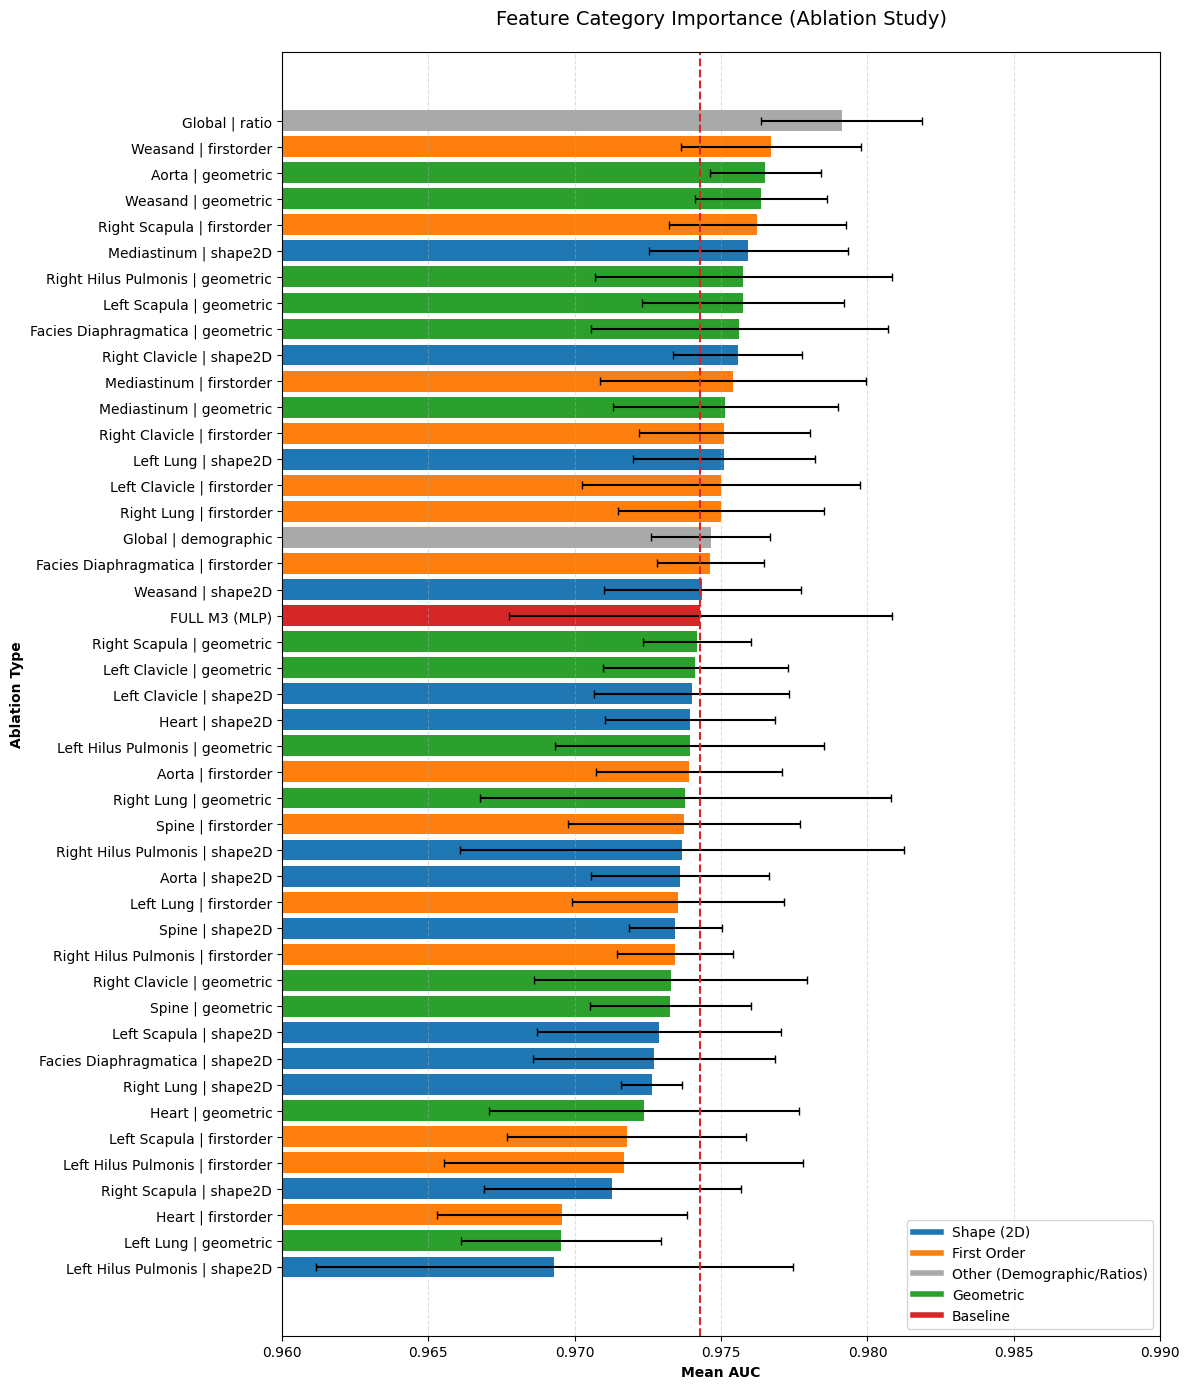

In [26]:
import matplotlib.pyplot as plt

# Define the color mapping logic
def get_color(category):
    if "shape2D" in category:
        return '#1f77b4'  # Professional blue
    elif "firstorder" in category:
        return '#ff7f0e'  # Professional orange
    elif "geometric" in category: # make green
        return '#2ca02c'  # Professional green
    elif "FULL" in category:
        return '#d62728'  # Professional red for baseline
    else:
        return '#a9a9a9'  # Dark gray for others

# Apply the colors based on the 'category' column
colors = ablation_results['category'].apply(get_color)

# Setup the horizontal bar chart
plt.figure(figsize=(12, 14)) 
bars = plt.barh(ablation_results['category'], ablation_results['mean_auc'], color=colors)

# Focus the view on the relevant AUC range
#
plt.xlim(0.96, 0.99)

# Labels and styling
plt.ylabel('Ablation Type', fontweight='bold')
plt.xlabel('Mean AUC', fontweight='bold')
plt.title('Feature Category Importance (Ablation Study)', fontsize=14, pad=20)
plt.grid(axis='x', linestyle='--', alpha=0.4)

# add std as error bars
plt.errorbar(ablation_results['mean_auc'], ablation_results['category'], xerr=ablation_results['std_auc'], fmt='none', ecolor='black', capsize=3)

# verticcal line at baseline
baseline_auc = ablation_results[ablation_results['category'] == 'FULL M3 (MLP)']['mean_auc'].values[0]
plt.axvline(x=baseline_auc, color='#d62728', linestyle='--', label='Baseline AUC')

# Optional: Add a legend to explain the colors
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='#1f77b4', lw=4, label='Shape (2D)'),
    Line2D([0], [0], color='#ff7f0e', lw=4, label='First Order'),
    Line2D([0], [0], color='#a9a9a9', lw=4, label='Other (Demographic/Ratios)'),
    Line2D([0], [0], color='#2ca02c', lw=4, label='Geometric'),
    Line2D([0], [0], color='#d62728', lw=4, label='Baseline')
    
]
plt.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

AUC drop by feature type:
 - First Order (Texture): 0.0023
 - Geometric: -0.0002
 - Other (Demographic/Ratios): -0.0040
 - Shape (2D): 0.0017


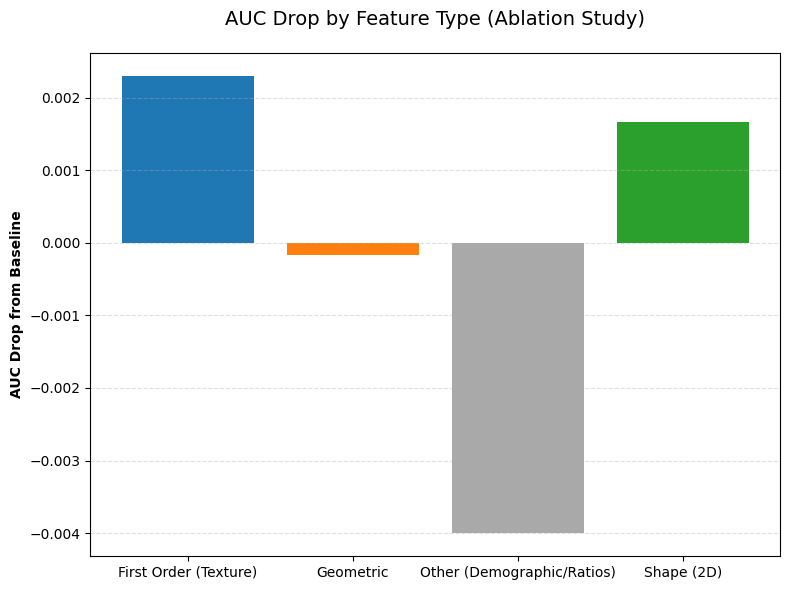

: 

In [ ]:
# Group and plot by category type (shape2D, firstorder, geometric, demographic)
ablation_results['type'] = ablation_results['category'].apply(lambda x: 'Shape (2D)' if 'shape2D' in x else ('First Order (Texture)' if 'firstorder' in x else ('Geometric' if 'geometric' in x else 'Other (Demographic/Ratios)')))
type_means = ablation_results.groupby('type')['mean_auc'].mean()
type_stds = ablation_results.groupby('type')['std_auc'].mean()
auc_drop = baseline_auc - type_means
print("AUC drop by feature type:")
for feature_type, drop in auc_drop.items():
    print(f" - {feature_type}: {drop:.4f}")
plt.figure(figsize=(8, 6))
# plot drop as bar chart
plt.bar(auc_drop.index, auc_drop.values, color=['#1f77b4', '#ff7f0e', '#a9a9a9', '#2ca02c'])
plt.ylabel('AUC Drop from Baseline', fontweight='bold')
plt.title('AUC Drop by Feature Type (Ablation Study)', fontsize=14, pad=20)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()